In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
print("Loading data...")
X_train = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Train/y_train.txt', sep=r'\s+', header=None)[0]
X_test = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Test/X_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Test/y_test.txt', sep=r'\s+', header=None)[0]

Loading data...


In [3]:
# Load activity labels
labels = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/activity_labels.txt', sep=r'\s+', header=None)
activity_map = dict(zip(labels[0], labels[1]))
y_train_mapped = y_train.map(activity_map)
y_test_mapped = y_test.map(activity_map)


In [4]:
print("Standardising & running PCA...")
scaler = StandardScaler()
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(scaler.fit_transform(X_train))
X_test_pca = pca.transform(scaler.transform(X_test))
print(f"Features reduced: {X_train.shape[1]} -> {X_train_pca.shape[1]}")

Standardising & running PCA...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extension

In [5]:
print("Running Grid Search...")
grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42), 
    {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1], 'kernel': ['rbf']}, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='f1_macro', n_jobs=-1, verbose=1
).fit(X_train_pca, y_train_mapped)

Running Grid Search...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 20

In [6]:
print(f"Best parameters: {grid.best_params_}")

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [7]:
print("Evaluating test set...")
y_pred = grid.predict(X_test_pca)
print("\n--- Classification Report ---")
print(classification_report(y_test_mapped, y_pred))

Evaluating test set...

--- Classification Report ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       545
        LIE_TO_SIT       0.73      0.76      0.75        25
      LIE_TO_STAND       0.73      0.59      0.65        27
           SITTING       0.93      0.90      0.91       508
        SIT_TO_LIE       0.71      0.69      0.70        32
      SIT_TO_STAND       0.90      0.90      0.90        10
          STANDING       0.91      0.94      0.93       556
      STAND_TO_LIE       0.73      0.78      0.75        49
      STAND_TO_SIT       0.90      0.78      0.84        23
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.94      0.89      0.92       420
  WALKING_UPSTAIRS       0.91      0.93      0.92       471

          accuracy                           0.93      3162
         macro avg       0.86      0.84      0.85      3162
      weighted avg       0.93      0.93     

Generating plot...


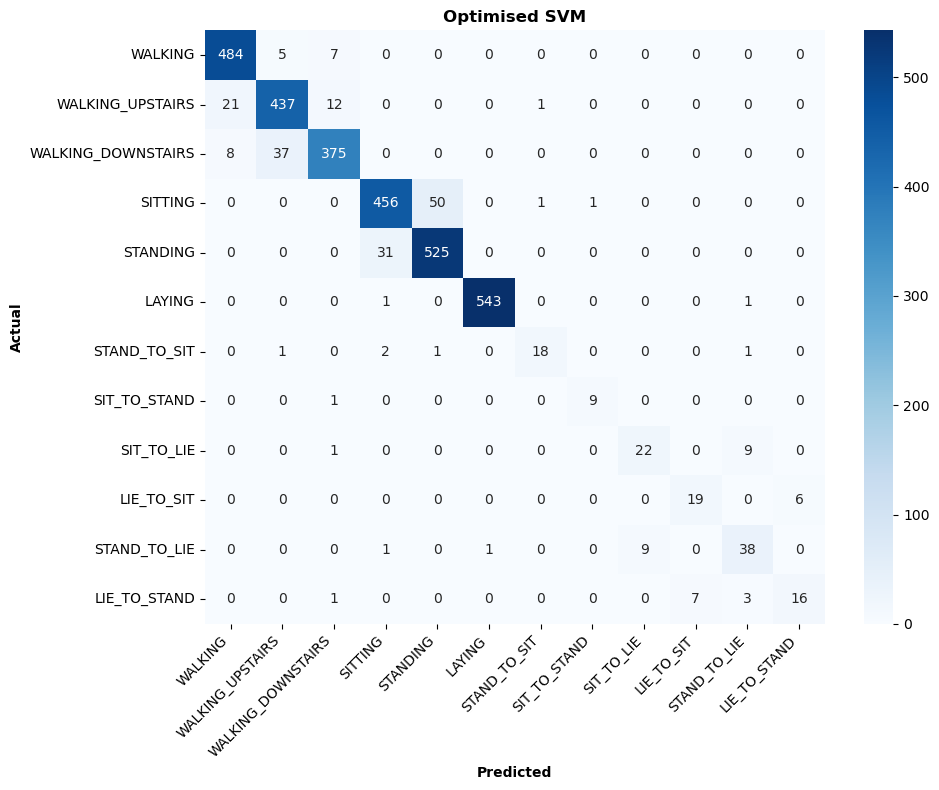

In [8]:
print("Generating plot...")
names = [activity_map[i] for i in sorted(activity_map.keys())]
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_mapped, y_pred, labels=names), annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.title('Optimised SVM', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()